###### Abschlussprojekt Big Data Machine Learning (2/4) - Ali Abdelatty (3539251)

## 2. Suchstrategien

### 2.1 Datensichtung

In [1]:
import pandas as pd
import numpy as np

##### 2.1.1 Daten einlesen

In [2]:
# Pfad zur Datei
file_path = 'data_v2/data_search_strategy/strategy_2/episode_0.csv'

# CSV einlesen
df = pd.read_csv(file_path, sep=';', decimal=',')

print("Datei erfolgreich eingelesen!")
print(f"Shape: {df.shape}")
print(f"\nErste 3 Zeilen:")
print(df.head(3))
print(f"\nSpalten: {list(df.columns)}")

Datei erfolgreich eingelesen!
Shape: (537, 24)

Erste 3 Zeilen:
   step  ros_timestamp  ft_wrench_fx  ft_wrench_fy  ft_wrench_fz  \
0     1         0.0373      0.009030     -0.007327      0.013962   
1     2         0.0674      0.016816     -0.009441           NaN   
2     3         0.0973      0.000432     -0.004174      0.018859   

   ft_wrench_tx  ft_wrench_ty  ft_wrench_tz  current_absolute_pose_x  \
0      0.014997           NaN     -0.007954                 0.617980   
1      0.019963      0.026257      0.009185                 0.618110   
2      0.007498      0.003826      0.019687                 0.618257   

   current_absolute_pose_y  ...  current_twist_wx  current_twist_wy  \
0                 0.120859  ...         -0.016705          0.024315   
1                 0.120863  ...          0.003619          0.015935   
2                 0.120840  ...          0.020861          0.009394   

   current_twist_wz  action_f_x  action_f_y  action_f_z  action_t_x  \
0         -0.02901

##### 2.1.2 Durchschnittliche Abtastzeit, Anzahl Steps, Gesamtdauer

In [3]:
# Zeitdifferenzen zwischen Steps berechnen (s)
time_diffs = df['ros_timestamp'].diff()

# Durchschnittliche Abtastzeit (ms)
avg_sampling_time_ms = time_diffs.mean() * 1000

# Anzahl Steps
num_steps = len(df)

# Gesamtdauer in ms
total_duration_ms = (df['ros_timestamp'].iloc[-1] - df['ros_timestamp'].iloc[0]) * 1000

print(f"Durchschnittliche Abtastzeit: {avg_sampling_time_ms:.2f} ms")
print(f"Anzahl Steps: {num_steps}")
print(f"Gesamtdauer der Installation: {total_duration_ms:.2f} ms")

Durchschnittliche Abtastzeit: 33.30 ms
Anzahl Steps: 537
Gesamtdauer der Installation: 17849.70 ms


##### 2.1.3 Fehlende Werte identifizieren

In [4]:
# Fehlende Werte zählen
missing_values = df.isnull().sum()

# Spalten mit fehlenden Werten filtern
columns_with_missing = missing_values[missing_values > 0]

if len(columns_with_missing) > 0:
    print(f"Ja, es gibt {missing_values.sum()} fehlende Werte.\n")
    print("Spalten mit fehlenden Werten:")
    for col, count in columns_with_missing.items():
        print(f"  {col}: {count} fehlende Werte")
else:
    print("Nein, keine fehlenden Werte vorhanden.")

Ja, es gibt 423 fehlende Werte.

Spalten mit fehlenden Werten:
  ft_wrench_fx: 48 fehlende Werte
  ft_wrench_fy: 30 fehlende Werte
  ft_wrench_fz: 26 fehlende Werte
  ft_wrench_tx: 37 fehlende Werte
  ft_wrench_ty: 55 fehlende Werte
  ft_wrench_tz: 45 fehlende Werte
  current_twist_vx: 39 fehlende Werte
  current_twist_vy: 36 fehlende Werte
  current_twist_vz: 36 fehlende Werte
  current_twist_wx: 24 fehlende Werte
  current_twist_wy: 18 fehlende Werte
  current_twist_wz: 25 fehlende Werte
  action_f_x: 1 fehlende Werte
  action_f_y: 2 fehlende Werte
  action_t_z: 1 fehlende Werte


##### 2.1.4 Fehlende Werte auffüllen

Am besten dazu eignet sich hier die **lineare Interpolation**, weil es sich hier um kontinuierlichhe Sensordaten handelt. Die linn.Intrpl. würde Nachbarwerte zur Schätzung nutzen und sorgt somit für "saubere" Übergänge. Im gegnsatz dazu würde forward-fill unebene Sprünge verursachen. Ansonsten könnte man immer fehlende Daten mit Nullen füllen, aber macht in diesem Kontext kein Sinn (entspricht abrupter Teleport oder Kraftverlust).

In [5]:
# Interpolation durchführen
df_filled = df.interpolate(method='linear', limit_direction='both')

# Überprüfung
missing_after = df_filled.isnull().sum().sum()
print(f"Fehlende Werte nach Interpolation: {missing_after}")

# Falls noch Werte fehlen (z.B. am Anfang/Ende), mit forward-fill/backfill auffüllen
if missing_after > 0:
    df_filled = df_filled.fillna(method='bfill').fillna(method='ffill')
    print(f"Verbleibende Werte mit forward/backward-fill aufgefüllt.")

print("\nDaten erfolgreich vervollständigt!")

Fehlende Werte nach Interpolation: 0

Daten erfolgreich vervollständigt!


##### 2.1.5 Value Function berechnen

**Berechnung: V = sum(y^t * r_t)**

In [6]:
# Discount-Faktor
gamma = 0.999

# Rewards extrahieren (Array)
rewards = df_filled['reward'].values

# Erstelle Array mit Exponenten
t_steps = np.arange(len(rewards))

# Vektorisiertes Potenzieren und Multiplizieren
discounted_rewards = (gamma ** t_steps) * rewards

# Summe bilden
V_pi = discounted_rewards.sum()

print(f"Value der Episode: {V_pi:.6f}")

Value der Episode: 0.584927


##### 2.1.6 Wie kann man schnellere Einsteckvorgänge präferieren?

Der Agent kann dazu motiviert werden schneller zu arbeiten, indem man die Reward-Funktion oder die Umgebungsparameter anpasst:

- Negative Belohnung pro Schritt: Dem Agenten wird für jeden einzelnen Zeitschritt ein kleiner negativer Reward (r_t = -1) gegeben. Der Agent lernt die Episode so schnell wie möglich abzuschließen, um so wenige "Strafen" wie möglich zu sammeln.
- Verwendung des Discount-Faktors: Rewards in der Zukunft geringer zu gewichten. Ein positiver Reward für den erfolgreichen Abschluss ist mathematisch viel mehr wert, wenn er nach 10 Schritten erreicht wird, als wenn er erst nach 100 Schritten erreicht wird (der Agent lernt durch den Discount-Faktor Ziele schneller zu erreichen)
- Direkter Bonus für Geschwindigkeit: Bewegungsgeschwindigkeit wird berechnet und mit dem Reward so multipliziert, dass bei höhere Geschwindigkeiten die gesamte Belohnung auch erhöht wird

-----

### 2. Visualisierung der Daten

In [7]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

##### 2.2.1 Histogramme für Kräfte und Momente (Ist vs. Soll)

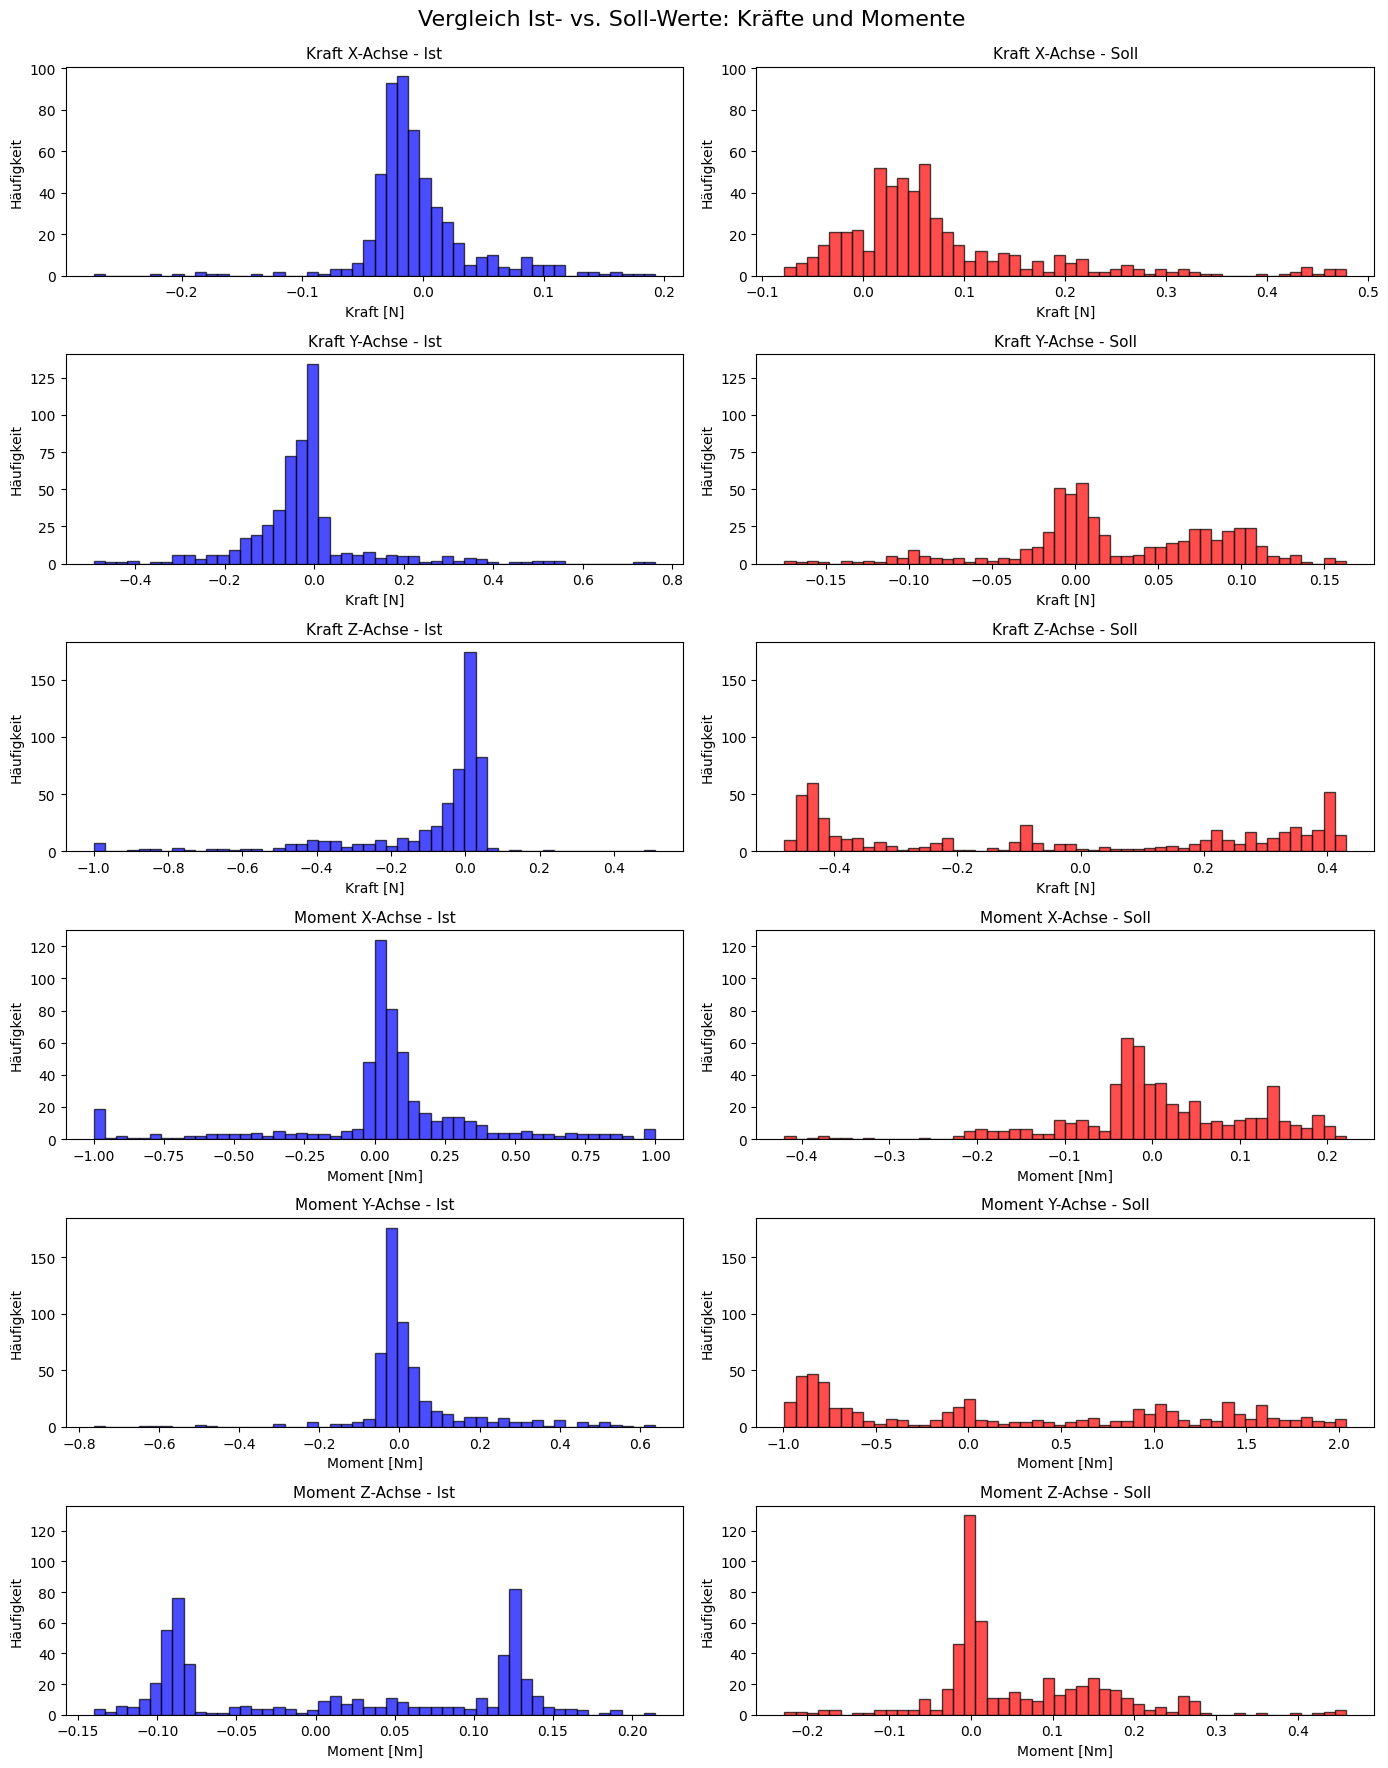

In [8]:
# Daten vorbereiten
kraft_ist = ['ft_wrench_fx', 'ft_wrench_fy', 'ft_wrench_fz']
kraft_soll = ['action_f_x', 'action_f_y', 'action_f_z']
moment_ist = ['ft_wrench_tx', 'ft_wrench_ty', 'ft_wrench_tz']
moment_soll = ['action_t_x', 'action_t_y', 'action_t_z']

achsen_label = ['X-Achse', 'Y-Achse', 'Z-Achse']

# Figure erstellen (6 Zeilen, 2 Spalten)
fig, axes = plt.subplots(6, 2, figsize=(14, 18))
fig.suptitle('Vergleich Ist- vs. Soll-Werte: Kräfte und Momente \n', fontsize=16)

# Kräfte plotten (Zeilen 0-2)
for i in range(3):
    # IST (links)
    ax_ist = axes[i, 0]
    data_ist = df_filled[kraft_ist[i]]
    ax_ist.hist(data_ist, bins=50, color='blue', edgecolor='black', alpha=0.7)
    ax_ist.set_title(f'Kraft {achsen_label[i]} - Ist', fontsize=11)
    ax_ist.set_xlabel('Kraft [N]')
    ax_ist.set_ylabel('Häufigkeit')
    
    # SOLL (rechts)
    ax_soll = axes[i, 1]
    data_soll = df_filled[kraft_soll[i]]
    ax_soll.hist(data_soll, bins=50, color='red', edgecolor='black', alpha=0.7)
    ax_soll.set_title(f'Kraft {achsen_label[i]} - Soll', fontsize=11)
    ax_soll.set_xlabel('Kraft [N]')
    ax_soll.set_ylabel('Häufigkeit')
    
    # Gleiche y-Achsen-Skala
    y_max = max(ax_ist.get_ylim()[1], ax_soll.get_ylim()[1])
    ax_ist.set_ylim(0, y_max)
    ax_soll.set_ylim(0, y_max)

# Momente plotten (Zeilen 3-5)
for i in range(3):
    # IST (links)
    ax_ist = axes[i+3, 0]
    data_ist = df_filled[moment_ist[i]]
    ax_ist.hist(data_ist, bins=50, color='blue', edgecolor='black', alpha=0.7)
    ax_ist.set_title(f'Moment {achsen_label[i]} - Ist', fontsize=11)
    ax_ist.set_xlabel('Moment [Nm]')
    ax_ist.set_ylabel('Häufigkeit')
    
    # SOLL (rechts)
    ax_soll = axes[i+3, 1]
    data_soll = df_filled[moment_soll[i]]
    ax_soll.hist(data_soll, bins=50, color='red', edgecolor='black', alpha=0.7)
    ax_soll.set_title(f'Moment {achsen_label[i]} - Soll', fontsize=11)
    ax_soll.set_xlabel('Moment [Nm]')
    ax_soll.set_ylabel('Häufigkeit')
    
    # Gleiche y-Achsen-Skala
    y_max = max(ax_ist.get_ylim()[1], ax_soll.get_ylim()[1])
    ax_ist.set_ylim(0, y_max)
    ax_soll.set_ylim(0, y_max)

plt.tight_layout()
plt.show()

##### 2.2.2 Auffälligkeiten und Ursachen

- Die Ist-Werte zeigen spitze Verteilungen um den Nullpunkt herum. Die Soll-Werte streuen generell viel stärker und decken breitere Wertebereiche ab als die Ist-Werte.
- Besonders auffällig ist die z-Achse: bei der Kraft z-Achse bei den Soll-Werten sieht man zwei deutliche Gruppen bei ca. -0.4N und +0.4N (der Agent will also aktiv nach oben oder nach unten). Die Ist-Werte zeigen jedoch fast nur Werte um 0N. Das deutet darauf hin, dass der Roboter Kraft aufbringen will, aber keinen Widerstand spürt.
- Moment Z-Achse (Umgekehrter Fall): Bei den Soll-Werten fordert der Agent fast nur 0Nm (das Handgelenk soll nicht verdreht werden). Die Ist-Werte zeigen jedoch zwei deutliche Peaks bei ca. -0.1Nm und +0.1Nm. Hier wirken physikalische Kräfte auf den Roboter, die er nicht aktiv steuert.
- **Mögliche Ursachen für den Unterschied zwischen Ist/Soll:** Während der Suchbewegung ist vielleicht kein Kontakt zur Buchse (Roboter versucht Bewegungen, spürt aber keinen Widerstand. Außerdem gibt es im System Kabel, Werkzeug, Gelenke die Nachgiebigkeit haben (Befehle führen nicht 1:1 zu gemessenen Kräften). Soll Befehle werden nicht direkt in Kräfte umgesetzt sondern durch Nachgiebigkeit gedämpft.

##### 2.2.3 Einsteckvorgang in der Autotür-Ebene plotten

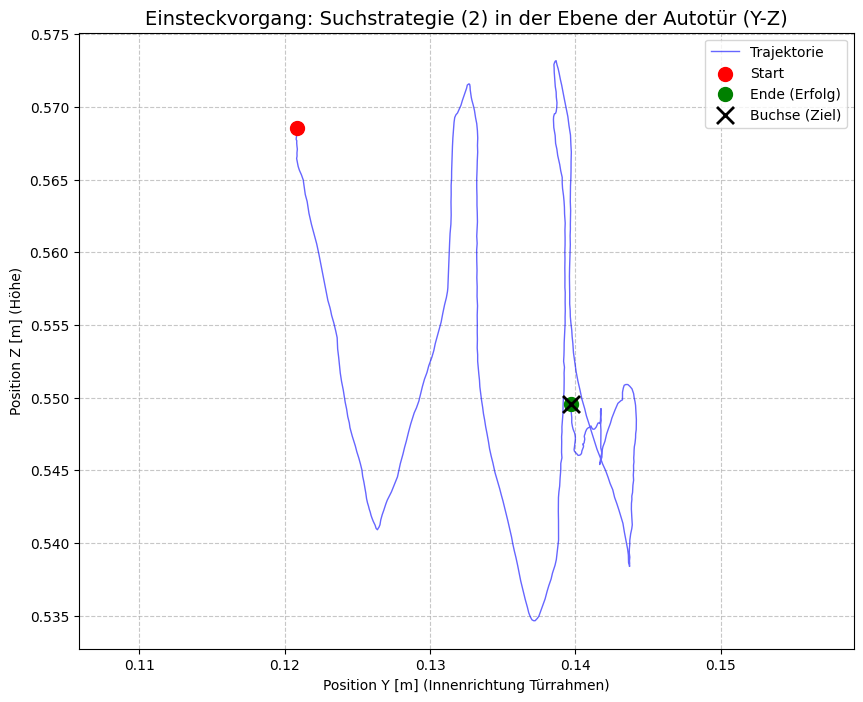

In [9]:
# Daten extrahieren
pos_y = df_filled['current_absolute_pose_y'].values
pos_z = df_filled['current_absolute_pose_z'].values

# Start- und Endpunkte
start_y, start_z = pos_y[0], pos_z[0]
end_y, end_z = pos_y[-1], pos_z[-1]

# Buchsenposiotion ist das Ziel der erfolgreichen Episode (der letzte Punkt)
buchse_y = end_y
buchse_z = end_z

plt.figure(figsize=(10, 8))

# Trajektorie plotten
plt.plot(pos_y, pos_z, label='Trajektorie', color='blue', alpha=0.6, linewidth=1)

# Startpunkt (Rot)
plt.scatter(start_y, start_z, color='red', s=100, label='Start', zorder=5)

# Endpunkt (Grün)
plt.scatter(end_y, end_z, color='green', s=100, label='Ende (Erfolg)', zorder=5)

# Buchse (X)
plt.scatter(buchse_y, buchse_z, color='black', marker='x', s=150, linewidth=2, label='Buchse (Ziel)', zorder=6)

# Labels und Titel
plt.title('Einsteckvorgang: Suchstrategie (2) in der Ebene der Autotür (Y-Z)', fontsize=14)
plt.xlabel('Position Y [m] (Innenrichtung Türrahmen)')
plt.ylabel('Position Z [m] (Höhe)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.axis('equal')
plt.show()

##### 2.2.4 Beschreibung der Suchstrategie des menschlichen Demonstrators

Der Startpunkt liegt links (rechts wenn man auf die Autotür zuguckt) oberhalb des Ziels. Der Demonstrator bewegt den Roboterarm zunächst weit nach unten und dann in einem weiten Bogen wieder nach oben über das Ziel hinaus.
Diese Bewegung ähnelt einer Abtastsuche oder einer groben Rasterung. Der Demonstrator tastet den Raum um das vermutete Zentrum herum ab (Wackeln), um durch physisches Feedback (Anstoßen am Rand oder Hineinrutschen) die Öffnung zu finden.
Finale Korrektur: Sobald der Roboterarm in die Nähe der Buchse (schwarzes Kreuz) kommt, werden die Bewegungen kleiner und zentrieren sich auf den Endpunkt, bis das erfolgreiche Einstecken gelingt.

##### 2.2.5 Alle Episoden einlesen und fehlende Werte auffüllen

In [10]:
# Dictionary zum Speichern aller Strategien
strategies = {}

# Alle 4 Strategien einlesen
for strategy_num in range(4):
    file_path = f'data_v2/data_search_strategy/strategy_{strategy_num}/episode_0.csv'
    
    # CSV einlesen
    df_strategy = pd.read_csv(file_path, sep=';', decimal=',')
    
    # Fehlende Werte mit linearer Interpolation auffüllen
    df_strategy = df_strategy.interpolate(method='linear', limit_direction='both')
    df_strategy = df_strategy.fillna(method='bfill').fillna(method='ffill')
    
    # Value Function berechnen
    gamma = 0.999
    T = len(df_strategy)
    discount_factors = np.array([gamma**t for t in range(T)])
    rewards = df_strategy['reward'].values
    V_pi = np.sum(discount_factors * rewards)
    
    # Speichern
    strategies[strategy_num] = {
        'df': df_strategy,
        'value': V_pi,
        'num_steps': T
    }
    
    print(f"Strategie {strategy_num}: {T} Steps, Value = {V_pi:.6f}")

print("\nAlle Strategien erfolgreich eingelesen und aufgefüllt!")

Strategie 0: 398 Steps, Value = 0.672200
Strategie 1: 205 Steps, Value = 0.000000
Strategie 2: 537 Steps, Value = 0.584927
Strategie 3: 180 Steps, Value = 0.836031

Alle Strategien erfolgreich eingelesen und aufgefüllt!


/var/folders/h1/7s_jyhrs0gd118jm5hmk18lw0000gn/T/ipykernel_25366/1945625699.py:13: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_strategy = df_strategy.fillna(method='bfill').fillna(method='ffill')
/var/folders/h1/7s_jyhrs0gd118jm5hmk18lw0000gn/T/ipykernel_25366/1945625699.py:13: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_strategy = df_strategy.fillna(method='bfill').fillna(method='ffill')
/var/folders/h1/7s_jyhrs0gd118jm5hmk18lw0000gn/T/ipykernel_25366/1945625699.py:13: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_strategy = df_strategy.fillna(method='bfill').fillna(method='ffill')
/var/folders/h1/7s_jyhrs0gd118jm5hmk18lw0000gn/T/ipykernel_25366/1945625699.py:13: FutureWarning: DataFrame.fillna with '

##### 2.2.6 Alle Suchstrategien plotten, sortiert nach Value

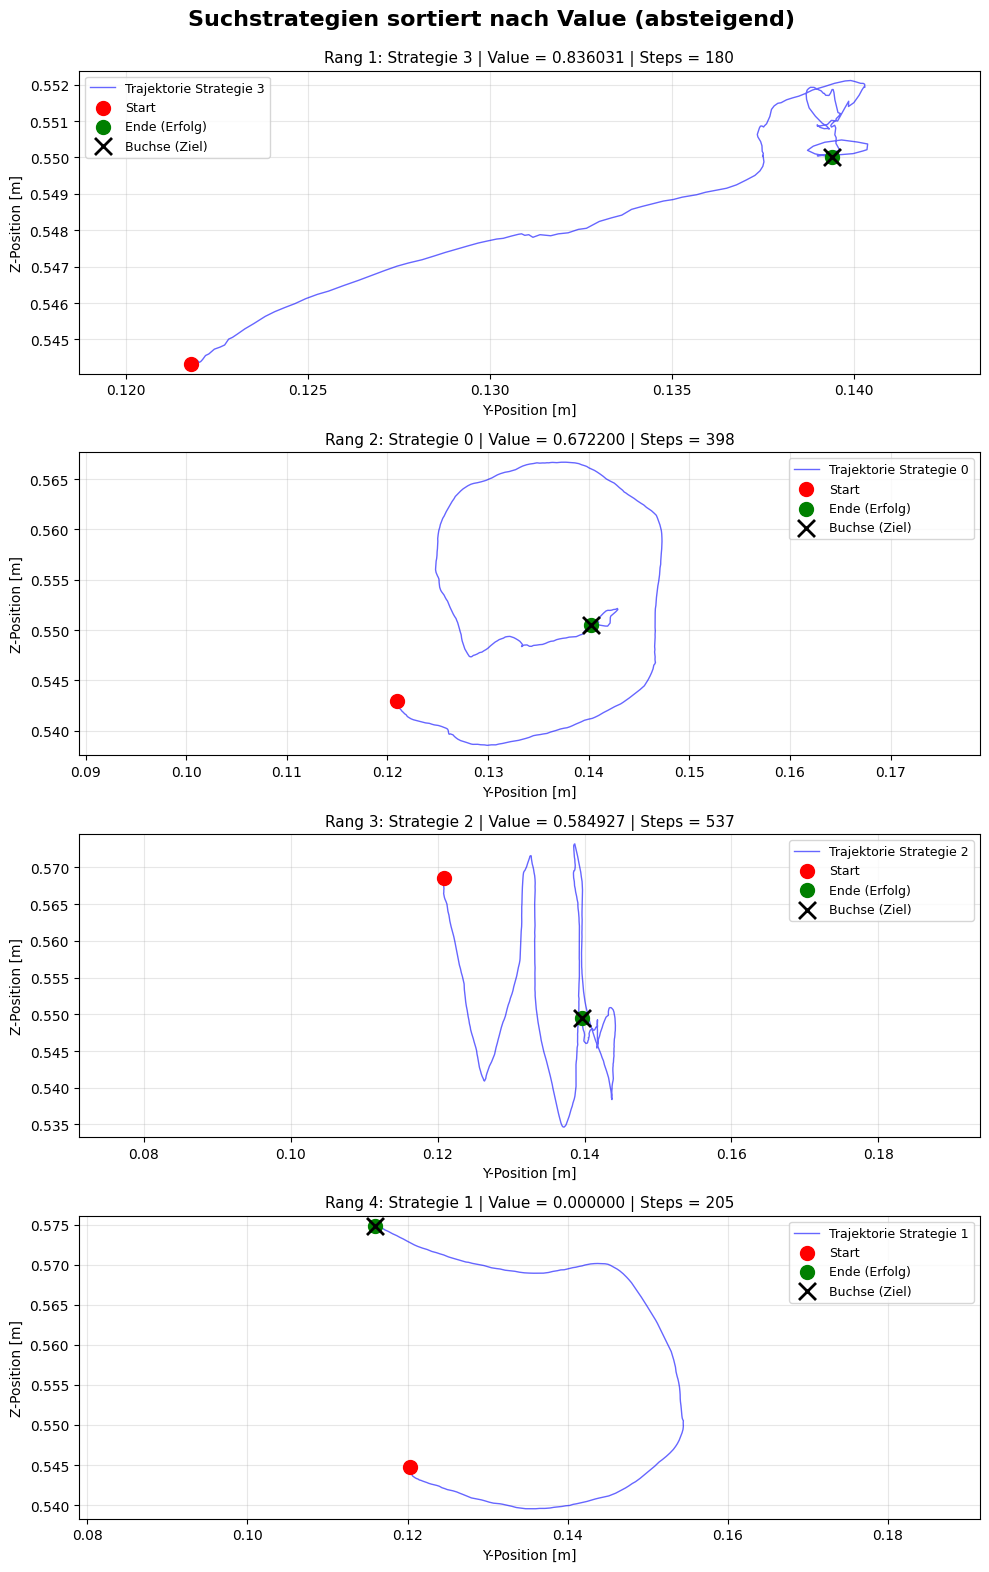


 Ranking nach Value
1. Strategie 3: Value = 0.836031, Steps = 180
2. Strategie 0: Value = 0.672200, Steps = 398
3. Strategie 2: Value = 0.584927, Steps = 537
4. Strategie 1: Value = 0.000000, Steps = 205


In [11]:
# Strategien nach Value sortieren (absteigend)
sorted_strategies = sorted(strategies.items(), key=lambda x: x[1]['value'], reverse=True)

# Figure mit 4 Zeilen erstellen
fig, axes = plt.subplots(4, 1, figsize=(10, 16))
fig.suptitle('Suchstrategien sortiert nach Value (absteigend) \n', fontsize=16, fontweight='bold')

# Für jede Strategie einen Plot erstellen
for i, (strategy_num, data) in enumerate(sorted_strategies):
    ax = axes[i]
    df_strat = data['df']
    
    # Positionen aus df extrahieren
    y_pos = df_strat['current_absolute_pose_y'].values
    z_pos = df_strat['current_absolute_pose_z'].values
    
    # Start-, End- & Buchsenpositionen
    start_y, start_z = y_pos[0], z_pos[0]
    end_y, end_z = y_pos[-1], z_pos[-1]
    buchse_y, buchse_z = end_y, end_z

    # Punkte & Trajektorie einzeichnen
    ax.plot(y_pos, z_pos, label=f'Trajektorie Strategie {strategy_num}', color='blue', alpha=0.6, linewidth=1)
    ax.scatter(start_y, start_z, color='red', s=100, label='Start', zorder=5)
    ax.scatter(end_y, end_z, color='green', s=100, label='Ende (Erfolg)', zorder=5)
    ax.scatter(buchse_y, buchse_z, color='black', marker='x', s=150, linewidth=2, label='Buchse (Ziel)', zorder=6)
    
    # Beschriftungen
    ax.set_xlabel('Y-Position [m]', fontsize=10)
    ax.set_ylabel('Z-Position [m]', fontsize=10)
    ax.set_title(f'Rang {i+1}: Strategie {strategy_num} | Value = {data["value"]:.6f} | Steps = {data["num_steps"]}', fontsize=11)
    ax.legend(loc='best', fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.axis('equal')

plt.tight_layout()
plt.show()

# Zusammenfassung ausgeben
print("\n Ranking nach Value")
for i, (strategy_num, data) in enumerate(sorted_strategies):
    print(f"{i+1}. Strategie {strategy_num}: Value = {data['value']:.6f}, Steps = {data['num_steps']}")

##### 2.2.7 Beschreibung der restlichen Suchstrategien

Basierend auf den sortierten Plots lassen sich vier unterschiedliche menschliche Herangehensweisen identifizieren:

- Strategie 3 (Zielstrebig/Direkt): Dies ist die erfolgreichste Strategie. Der Demonstrator führt den Stecker fast auf einer direkten Linie zum Ziel und korrigiert nur am Ende minimal nach. Mit nur 180 Schritten ist dies der schnellste Vorgang (am wenigsten bestraft).

- Strategie 0 (Spirale): Hier wurde eine kreisförmige Suchbewegung um das vermutete Zentrum herum durchgeführt.

- Strategie 2 (Zick-Zack/Abtasten): Diese Strategie zeigt starke vertikale Ausschläge. Es wirkt, als hätte der Demonstrator die Buchse mehrfach knapp verfehlt und musste mit 537 Schritten am längsten suchen.

- Strategie 1 (Gescheitert/Abbruch): Die Trajektorie zeigt einen weiten Bogen, der jedoch weit vom Ziel entfernt endet. Da der Value 0 ist und der Endpunkt nicht mit den anderen Zielpositionen übereinstimmt, ist dieser Versuch vermutlich fehlgeschlagen und wurde vorzeitig beendet.

Rang so sortiert wegen Diskontierung (Längere Episoden werden durch γ=0.999 bestraft)

##### 2.2.8 Suchstrategien als 3D-Plots

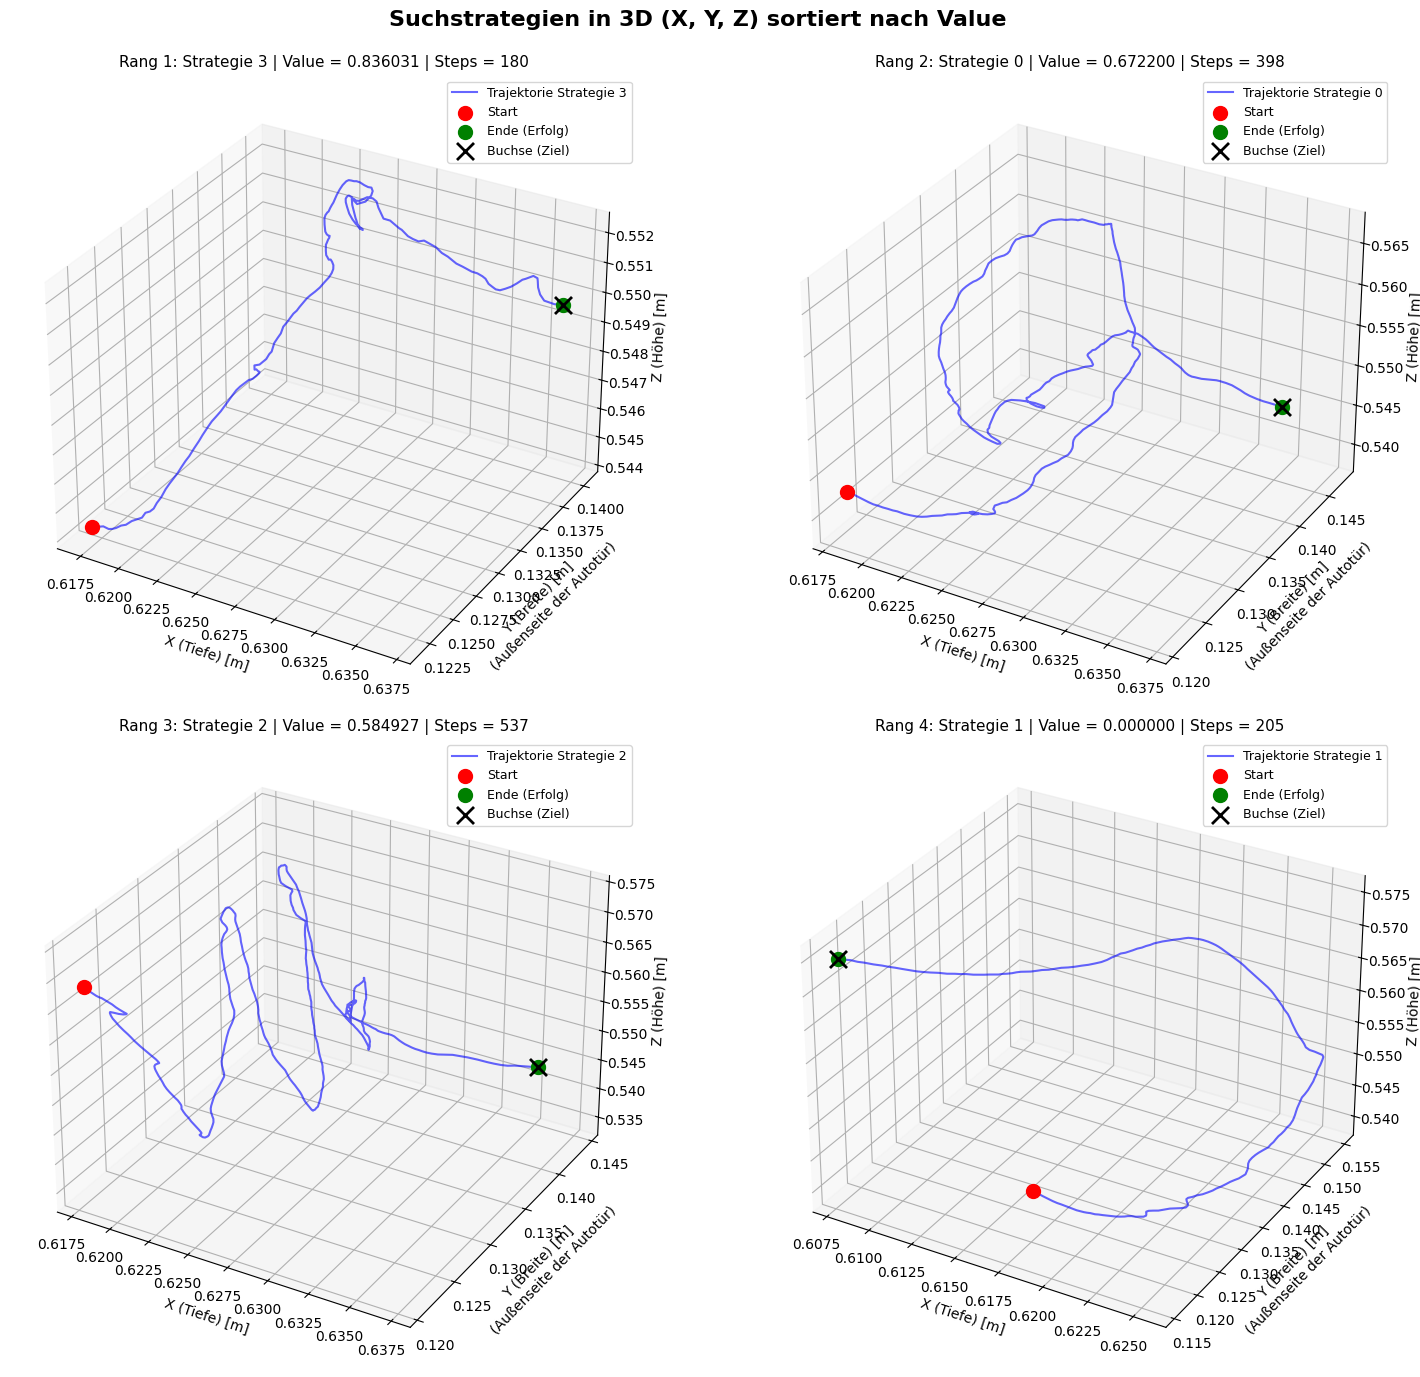

In [13]:
# Figure mit 2x2 Grid für alle 4 Strategien
fig = plt.figure(figsize=(16, 14))
fig.suptitle('Suchstrategien in 3D (X, Y, Z) sortiert nach Value \n', fontsize=16, fontweight='bold')

# Für jede Strategie einen 3D-Plot erstellen
for i, (strategy_num, data) in enumerate(sorted_strategies):
    ax = fig.add_subplot(2, 2, i+1, projection='3d')
    df_strat = data['df']
    
    # Positionen aus df extrahieren
    x_pos = df_strat['current_absolute_pose_x'].values
    y_pos = df_strat['current_absolute_pose_y'].values
    z_pos = df_strat['current_absolute_pose_z'].values
    
    # Start-, End- & Buchsenpositionen
    start_x, start_y, start_z = x_pos[0], y_pos[0], z_pos[0]
    end_x, end_y, end_z = x_pos[-1], y_pos[-1], z_pos[-1]
    buchse_x, buchse_y, buchse_z = end_x, end_y, end_z
    
    # Punkte & Trajektorie einzeichnen
    ax.plot(x_pos, y_pos, z_pos, color='blue', alpha=0.6, linewidth=1.5, label=f'Trajektorie Strategie {strategy_num}')
    ax.scatter(start_x, start_y, start_z, color='red', s=100, label='Start', zorder=5)
    ax.scatter(end_x, end_y, end_z, color='green', s=100, label='Ende (Erfolg)', zorder=5)
    ax.scatter(buchse_x, buchse_y, buchse_z, color='black', marker='x', s=150, linewidth=2, label='Buchse (Ziel)', zorder=6)
    
    # Beschriftungen
    ax.set_xlabel('X (Tiefe) [m]', fontsize=10)
    ax.set_ylabel('Y (Breite) [m] \n (Außenseite der Autotür)', fontsize=10)
    ax.set_zlabel('Z (Höhe) [m]', fontsize=10)
    ax.set_title(f'Rang {i+1}: Strategie {strategy_num} | Value = {data["value"]:.6f} | Steps = {data["num_steps"]}', fontsize=11)
    ax.legend(loc='best', fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()